In [6]:
import numpy as np
import matplotlib.pyplot as plt

def compute_gradient(phi, x, y, h=1e-5):
    """
    Compute the gradient of a scalar field phi(x,y)
    using central finite differences.
    """
    # Compute partial derivatives
    dphi_dx = (phi(x + h, y) - phi(x - h, y)) / (2 * h)
    dphi_dy = (phi(x, y + h) - phi(x, y - h)) / (2 * h)
    
    return dphi_dx, dphi_dy

# Define the scalar potential phi(x,y) = xy
def phi(x, y):
    return x * y


Maximum error in x-component: 3.14e-11
Maximum error in y-component: 3.14e-11


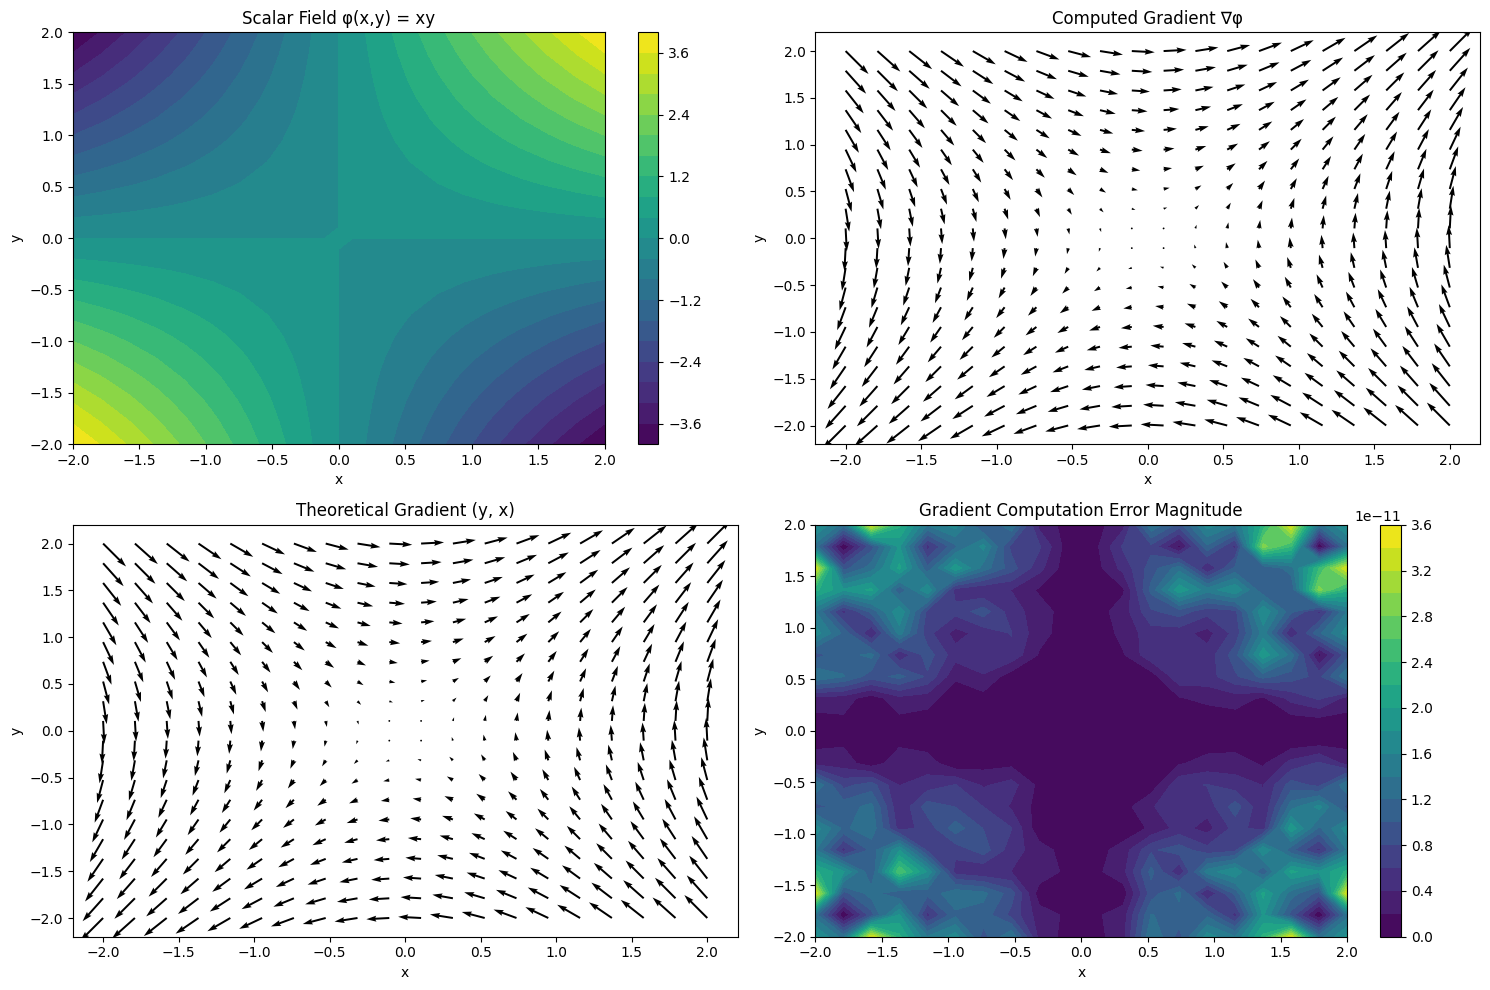

In [7]:

# Create a grid of points
x = np.linspace(-2, 2, 20)
y = np.linspace(-2, 2, 20)
X, Y = np.meshgrid(x, y)

# Compute the gradient
grad_x, grad_y = compute_gradient(phi, X, Y)

# Theoretical gradient should be (y, x)
theoretical_grad_x = Y
theoretical_grad_y = X

# Calculate the error
error_x = np.abs(grad_x - theoretical_grad_x)
error_y = np.abs(grad_y - theoretical_grad_y)

print(f"Maximum error in x-component: {np.max(error_x):.2e}")
print(f"Maximum error in y-component: {np.max(error_y):.2e}")

# Visualization
plt.figure(figsize=(15, 10))

# Plot the scalar field
plt.subplot(2, 2, 1)
contour = plt.contourf(X, Y, phi(X, Y), levels=20)
plt.colorbar(contour)
plt.title('Scalar Field φ(x,y) = xy')
plt.xlabel('x')
plt.ylabel('y')

# Plot the computed gradient
plt.subplot(2, 2, 2)
plt.quiver(X, Y, grad_x, grad_y)
plt.title('Computed Gradient ∇φ')
plt.xlabel('x')
plt.ylabel('y')

# Plot the theoretical gradient (y, x)
plt.subplot(2, 2, 3)
plt.quiver(X, Y, Y, X)
plt.title('Theoretical Gradient (y, x)')
plt.xlabel('x')
plt.ylabel('y')

# Plot the error magnitude
plt.subplot(2, 2, 4)
error_magnitude = np.sqrt(error_x**2 + error_y**2)
error_contour = plt.contourf(X, Y, error_magnitude, levels=20)
plt.colorbar(error_contour)
plt.title('Gradient Computation Error Magnitude')
plt.xlabel('x')
plt.ylabel('y')

plt.tight_layout()
plt.show()


Curl at (1, 1, 0): 0.0 0.0 -1.9754100853752732
Curl at (-1, 2, 0): 0.0 0.0 -1.4436660217054254


Text(0, 0.5, 'y')

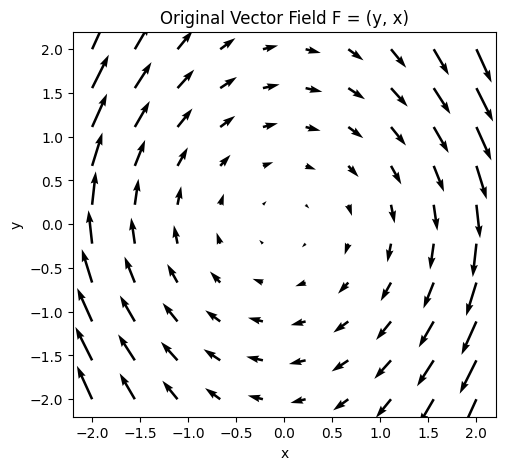

In [8]:

def compute_curl(F, x, y, z, h=1e-5):
    """
    Compute the curl of a vector field F = (Fx, Fy, Fz) at points (x, y, z)
    using finite differences with step size h.
    """
    # Initialize curl components
    curl_x = np.zeros_like(x)
    curl_y = np.zeros_like(y)
    curl_z = np.zeros_like(z)
    
    # Compute partial derivatives using central differences
    # dFz/dy - dFy/dz
    curl_x = (F[2](x, y+h, z) - F[2](x, y-h, z)) / (2*h) - \
             (F[1](x, y, z+h) - F[1](x, y, z-h)) / (2*h)
    
    # dFx/dz - dFz/dx
    curl_y = (F[0](x, y, z+h) - F[0](x, y, z-h)) / (2*h) - \
             (F[2](x+h, y, z) - F[2](x-h, y, z)) / (2*h)
    
    # dFy/dx - dFx/dy
    curl_z = (F[1](x+h, y, z) - F[1](x-h, y, z)) / (2*h) - \
             (F[0](x, y+h, z) - F[0](x, y-h, z)) / (2*h)
    
    return curl_x, curl_y, curl_z

# Define the vector field F = (y, x, 0)
def Fx(x, y, z):
    return np.sin(y) #np.cos(x) #np.sin(y)

def Fy(x, y, z):
    return -x #-np.sin(y) #-x

def Fz(x, y, z):
    return 0

F = (Fx, Fy, Fz)

# Create a grid of points
x = np.linspace(-2, 2, 10)
y = np.linspace(-2, 2, 10)
z = np.linspace(-2, 2, 10)
X, Y, Z = np.meshgrid(x, y, z)

# Compute the curl
curl_x, curl_y, curl_z = compute_curl(F, X, Y, Z)

# Print the curl at some points to verify it's (0, 0, 0)
print("Curl at (1, 1, 0):", curl_x[5,5,5], curl_y[5,5,5], curl_z[5,5,5])
print("Curl at (-1, 2, 0):", curl_x[2,7,5], curl_y[2,7,5], curl_z[2,7,5])

# Visualization (2D slice at z=0 for simplicity)
plt.figure(figsize=(12, 5))

# Plot the original vector field
plt.subplot(1, 2, 1)
plt.quiver(X[:,:,5], Y[:,:,5], Fx(X[:,:,5], Y[:,:,5], Z[:,:,5]), 
           Fy(X[:,:,5], Y[:,:,5], Z[:,:,5]))
plt.title('Original Vector Field F = (y, x)')
plt.xlabel('x')
plt.ylabel('y')


c:\Users\jeand\AppData\Local\Programs\Python\Python313\Lib\site-packages\matplotlib\quiver.py:695: RuntimeWarning: divide by zero encountered in scalar divide
  length = a * (widthu_per_lenu / (self.scale * self.width))
c:\Users\jeand\AppData\Local\Programs\Python\Python313\Lib\site-packages\matplotlib\quiver.py:695: RuntimeWarning: invalid value encountered in multiply
  length = a * (widthu_per_lenu / (self.scale * self.width))


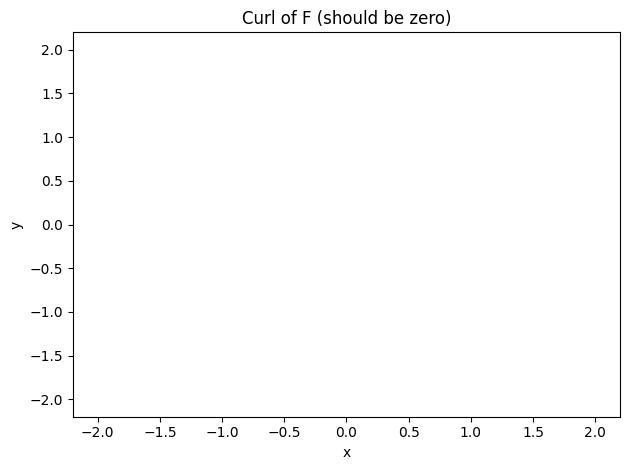

In [11]:

# Plot the curl (should be zero everywhere)
#plt.subplot(1, 2, 2)
plt.quiver(X[:,:,5], Y[:,:,5], curl_x[:,:,5], curl_y[:,:,5])
plt.title('Curl of F (should be zero)')
plt.xlabel('x')
plt.ylabel('y')

plt.tight_layout()
plt.show()


In [12]:
def compute_divergence(F, x, y, z, h=1e-5):
    """
    Compute the divergence of a vector field F = (Fx, Fy, Fz) at points (x, y, z)
    using finite differences with step size h.
    """
    # Compute partial derivatives using central differences
    dFx_dx = (F[0](x+h, y, z) - F[0](x-h, y, z)) / (2*h)
    dFy_dy = (F[1](x, y+h, z) - F[1](x, y-h, z)) / (2*h)
    dFz_dz = (F[2](x, y, z+h) - F[2](x, y, z-h)) / (2*h)
    
    return dFx_dx + dFy_dy + dFz_dz

# Define the vector field F = (y, x, 0)
def Fx(x, y, z):
    return np.cos(x)

def Fy(x, y, z):
    return np.sin(y)

def Fz(x, y, z):
    return 0

F = (Fx, Fy, Fz)


Divergence at (1, 1): 0.8893960736944261
Divergence at (-1, 2): -0.33213872293047497


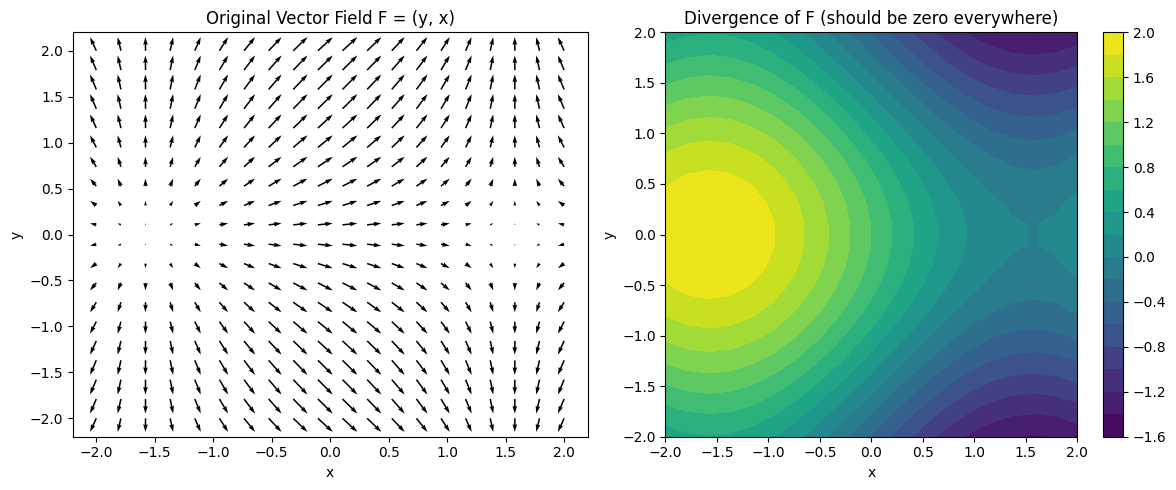

In [ ]:
## Divergence of a vector field
# Create a grid of points
x = np.linspace(-2, 2, 20)
y = np.linspace(-2, 2, 20)
z = np.linspace(0, 0, 1)  # 2D plane at z=0
X, Y, Z = np.meshgrid(x, y, z)

# Compute the divergence
divergence = compute_divergence(F, X, Y, Z)

# Print the divergence at some points to verify it's 0
print("Divergence at (1, 1):", divergence[10, 10, 0])
print("Divergence at (-1, 2):", divergence[5, 15, 0])

# Visualization
plt.figure(figsize=(12, 5))

# Plot the original vector field
plt.subplot(1, 2, 1)
plt.quiver(X[:, :, 0], Y[:, :, 0], Fx(X[:, :, 0], Y[:, :, 0], Z[:, :, 0]), 
           Fy(X[:, :, 0], Y[:, :, 0], Z[:, :, 0]))
plt.title('Original Vector Field F = (y, x)')
plt.xlabel('x')
plt.ylabel('y')

# Plot the divergence (should be zero everywhere)
plt.subplot(1, 2, 2)
div_plot = plt.contourf(X[:, :, 0], Y[:, :, 0], divergence[:, :, 0], levels=20)
plt.colorbar(div_plot)
plt.title('Divergence of F (should be zero everywhere)')
plt.xlabel('x')
plt.ylabel('y')

plt.tight_layout()
plt.show()
